# Comparação ADF × CRDW — Testes de Cointegração

Notebook auxiliar que roda os **quatro cenários** de teste de cointegração sobre o mesmo
conjunto de pares candidatos (top-N por SSD de um período de formação) e compara onde eles
concordam e divergem:

| Cenário | Teste | Direção |
|---|---|---|
| `adf_uni`  | ADF (MacKinnon) | unilateral (Q2~Q1) |
| `adf_bi`   | ADF (MacKinnon) | bilateral (aprova só se ambas passarem) |
| `crdw_uni` | CRDW (Engle-Granger 1987) | unilateral |
| `crdw_bi`  | CRDW (Engle-Granger 1987) | bilateral |

**Objetivo:** material metodológico para o TCC — quantificar o efeito de (a) trocar ADF por
CRDW e (b) exigir bilateralidade. Os pares onde os métodos **divergem** são os mais
interessantes para discussão.

- **ADF** — estatística muito **negativa** = estacionário. Aprova se `stat < CRIT_COINT_5PCT` (−3.34).
- **CRDW** — Durbin-Watson do resíduo, `DW ≈ 2(1−ρ)`. Longe de zero = estacionário. Aprova se `stat > CRIT_CRDW_5PCT`, com o crítico **reescalado pelo tamanho de amostra** (`0.386 × 100/T`, ≈0.153 para T≈252) — ver célula 2. O valor de tabela 0.386 vale só para T≈100; em dados diários persistentes ele rejeitaria quase tudo.

**Referências:** Engle & Granger (1987); MacKinnon (1991/2010); Rad, Low & Faff (2016).

## 1. Setup e parâmetros

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson

warnings.filterwarnings('ignore')

# ── Período de formação a analisar (12 meses) ────────────────────────────────
FORM_INICIO = '2014-01'   # mês inicial da janela de formação (YYYY-MM)
MESES_FORMACAO = 12

# ── Candidatos ────────────────────────────────────────────────────────────────
TOP_N_SSD = 100   # nº de pares de menor SSD a testar
SSD_MIN   = 0.01  # descarta ghost tickers (SSD ≈ 0)

# ── Valores críticos (5%) ─────────────────────────────────────────────────────
CRIT_COINT_5PCT    = -3.34   # ADF, MacKinnon 5%, 2 variáveis
CRDW_CRIT_REF_T100 = 0.386   # CRDW base: valor de tabela Engle-Granger (1987) p/ T≈100
# O CRDW (DW ≈ 2(1−ρ₁)) é baixo em dados diários porque o spread é persistente. Como a
# distribuição nula escala com 1/T, o valor crítico efetivo é reescalado pelo tamanho da
# janela — definido na célula seguinte (após conhecer T): crit(T) = 0.386 × 100/T (≈0.153
# para T≈252). Aplicar 0.386 direto exigiria meia-vida de reversão de ~3 dias.

META_COLS = ['year', 'semester', 'period', 'day_in_semester', 'total_days_sem']

## 2. Carregando os dados e recortando a janela de formação

In [2]:
df = pd.read_csv('../../data_bases/base_unificada.csv', parse_dates=['date']).set_index('date')
colunas_preco   = [c for c in df.columns if c not in META_COLS]
meses_por_linha = pd.PeriodIndex(df.index, freq='M')

p_inicio = pd.Period(FORM_INICIO, freq='M')
p_fim    = p_inicio + (MESES_FORMACAO - 1)
mask     = (meses_por_linha >= p_inicio) & (meses_por_linha <= p_fim)

precos = df.loc[mask, colunas_preco].dropna(axis=1, how='any')
Q      = precos.div(precos.iloc[0])   # Q_i(t) = P_i(t)/P_i(0)

# Valor crítico do CRDW reescalado para o T real da janela (dist. nula ~ 1/T)
CRIT_CRDW_5PCT = CRDW_CRIT_REF_T100 * 100 / Q.shape[0]

print(f"Janela de formação : {p_inicio} → {p_fim}")
print(f"Dias de pregão (T) : {Q.shape[0]}")
print(f"Ativos completos   : {Q.shape[1]}")
print(f"CRDW crítico 5%    : {CRIT_CRDW_5PCT:.3f}   (reescalado de {CRDW_CRIT_REF_T100} @ T=100)")

Janela de formação : 2014-01 → 2014-12
Dias de pregão (T) : 252
Ativos completos   : 620
CRDW crítico 5%    : 0.153   (reescalado de 0.386 @ T=100)


## 3. Funções — SSD, candidatos e teste unificado

`testar_cointegracao` é a mesma lógica de `pairs_formation_coint`, parametrizada por
`metodo` ('ADF'/'CRDW') e `bilateral` (True/False).

In [3]:
def calcular_ssd(Q):
    arr   = Q.values
    G     = arr.T @ arr
    norms = np.diag(G)
    ssd   = norms[:, None] + norms[None, :] - 2 * G
    return pd.DataFrame(ssd, index=Q.columns, columns=Q.columns)


def mesmo_emissor(t1, t2):
    def base(t):
        t = re.sub(r'[._][A-Z]$', '', t)
        if len(t) > 2 and t[-1] in 'ABCKL':
            t = t[:-1]
        return t
    return base(t1) == base(t2)


def selecionar_candidatos_ssd(ssd_df, n):
    tickers = ssd_df.columns.tolist()
    i_idx, j_idx = np.triu_indices(len(tickers), k=1)
    ssds = ssd_df.values[i_idx, j_idx]
    validos = np.array([
        k for k in range(len(i_idx))
        if ssds[k] >= SSD_MIN and not mesmo_emissor(tickers[i_idx[k]], tickers[j_idx[k]])
    ])
    if len(validos) == 0:
        return []
    i_idx, j_idx, ssds = i_idx[validos], j_idx[validos], ssds[validos]
    order = np.argsort(ssds)[:n]
    return [(tickers[i_idx[k]], tickers[j_idx[k]], float(ssds[k])) for k in order]


def _ols_residuo(y_arr, x_arr):
    X      = sm.add_constant(x_arr, has_constant='add')
    model  = sm.OLS(y_arr, X).fit()
    params = np.asarray(model.params)
    return float(params[0]), float(params[1]), model.resid


def _estatistica_residuo(residuo, metodo):
    if metodo == 'ADF':
        stat   = adfuller(residuo, autolag='AIC', regression='n')[0]
        passou = stat < CRIT_COINT_5PCT
    elif metodo == 'CRDW':
        stat   = durbin_watson(residuo)
        passou = stat > CRIT_CRDW_5PCT
    else:
        raise ValueError(f"Método desconhecido: {metodo!r}")
    return stat, passou


def testar_cointegracao(q_a, q_b, metodo, bilateral):
    a_arr = np.asarray(q_a, dtype=float)
    b_arr = np.asarray(q_b, dtype=float)
    falha = {'cointegrado': False, 'stat': np.nan, 'direcao': None}
    if a_arr.std() < 1e-10 or b_arr.std() < 1e-10:
        return falha

    _, _, resid1   = _ols_residuo(b_arr, a_arr)   # B ~ A
    stat1, passou1 = _estatistica_residuo(resid1, metodo)

    if not bilateral:
        return {'cointegrado': passou1, 'stat': float(stat1), 'direcao': 'B~A'} if passou1 \
               else {'cointegrado': False, 'stat': float(stat1), 'direcao': 'B~A'}

    _, _, resid2   = _ols_residuo(a_arr, b_arr)   # A ~ B
    stat2, passou2 = _estatistica_residuo(resid2, metodo)
    cointegrado = passou1 and passou2

    if metodo == 'ADF':
        escolhe_1 = stat1 <= stat2
    else:
        escolhe_1 = stat1 >= stat2
    stat_forte = stat1 if escolhe_1 else stat2
    direcao    = 'B~A' if escolhe_1 else 'A~B'
    return {'cointegrado': cointegrado, 'stat': float(stat_forte), 'direcao': direcao}

## 4. Rodando os quatro cenários sobre os candidatos

In [4]:
ssd_df     = calcular_ssd(Q)
candidatos = selecionar_candidatos_ssd(ssd_df, TOP_N_SSD)
print(f"Pares candidatos (top-{TOP_N_SSD} SSD): {len(candidatos)}")

registros = []
for a, b, ssd in candidatos:
    Qa, Qb = Q[a].values, Q[b].values

    r_adf_uni  = testar_cointegracao(Qa, Qb, metodo='ADF',  bilateral=False)
    r_adf_bi   = testar_cointegracao(Qa, Qb, metodo='ADF',  bilateral=True)
    r_crdw_uni = testar_cointegracao(Qa, Qb, metodo='CRDW', bilateral=False)
    r_crdw_bi  = testar_cointegracao(Qa, Qb, metodo='CRDW', bilateral=True)

    registros.append({
        'par':       f"{a}-{b}",
        'ssd':       round(ssd, 4),
        'adf_stat':  round(r_adf_uni['stat'], 3),
        'adf_uni':   r_adf_uni['cointegrado'],
        'adf_bi':    r_adf_bi['cointegrado'],
        'crdw_stat': round(r_crdw_uni['stat'], 3),
        'crdw_uni':  r_crdw_uni['cointegrado'],
        'crdw_bi':   r_crdw_bi['cointegrado'],
    })

df_comp = pd.DataFrame(registros)
df_comp['concordam_uni'] = df_comp['adf_uni'] == df_comp['crdw_uni']
df_comp.head(15)

Pares candidatos (top-100 SSD): 100


,par,ssd,adf_stat,adf_uni,adf_bi,crdw_stat,crdw_uni,crdw_bi,concordam_uni
0,BF_B-1958Q,0.0432,-15.935,True,True,2.015,True,True,True
1,MHFI-SPGI,0.0491,-14.755,True,True,1.862,True,True,True
2,AEP-CMS,0.0662,-2.851,False,False,0.235,True,True,False
3,XEL-CMS,0.0756,-4.003,True,True,0.238,True,True,True
4,EQR-AVB,0.0795,-3.292,False,False,0.163,True,True,False
5,K-GIS,0.0799,-4.285,True,True,0.267,True,True,True
6,MMM-ITW,0.0952,-3.232,False,False,0.219,True,True,False
7,CVS-ALL,0.1045,-4.454,True,True,0.304,True,True,True
8,STI-USB,0.1047,-2.980,False,False,0.137,False,False,True
9,HIG-BLK,0.1080,-3.894,True,True,0.229,True,True,True


## 5. Estatísticas de concordância

In [5]:
n = len(df_comp)
print(f"Pares testados                 : {n}\n")

print("── Aprovações (unilateral) ──")
print(f"ADF  aprovou                   : {df_comp['adf_uni'].sum()}  ({df_comp['adf_uni'].mean():.0%})")
print(f"CRDW aprovou                   : {df_comp['crdw_uni'].sum()}  ({df_comp['crdw_uni'].mean():.0%})")
print(f"Ambos aprovaram (interseção)   : {(df_comp['adf_uni'] & df_comp['crdw_uni']).sum()}")
print(f"Só ADF                         : {(df_comp['adf_uni'] & ~df_comp['crdw_uni']).sum()}")
print(f"Só CRDW                        : {(~df_comp['adf_uni'] & df_comp['crdw_uni']).sum()}")
print(f"Concordância (mesmo veredito)  : {df_comp['concordam_uni'].mean():.0%}")

print("\n── Efeito da bilateralidade ──")
print(f"ADF : uni aprovou mas bi reprovou  : {(df_comp['adf_uni'] & ~df_comp['adf_bi']).sum()}")
print(f"CRDW: uni aprovou mas bi reprovou  : {(df_comp['crdw_uni'] & ~df_comp['crdw_bi']).sum()}")
print(f"ADF  bilateral aprovou             : {df_comp['adf_bi'].sum()}  ({df_comp['adf_bi'].mean():.0%})")
print(f"CRDW bilateral aprovou             : {df_comp['crdw_bi'].sum()}  ({df_comp['crdw_bi'].mean():.0%})")

Pares testados                 : 100

── Aprovações (unilateral) ──
ADF  aprovou                   : 48  (48%)
CRDW aprovou                   : 64  (64%)
Ambos aprovaram (interseção)   : 43
Só ADF                         : 5
Só CRDW                        : 21
Concordância (mesmo veredito)  : 74%

── Efeito da bilateralidade ──
ADF : uni aprovou mas bi reprovou  : 7
CRDW: uni aprovou mas bi reprovou  : 2
ADF  bilateral aprovou             : 41  (41%)
CRDW bilateral aprovou             : 62  (62%)


## 6. Scatter — ADF vs CRDW

Cada ponto é um par. Linhas tracejadas marcam os valores críticos (CRDW reescalado para o T da janela).
O quadrante **inferior-direito** (ADF < −3.34 **e** CRDW > crit(T)) é onde os dois métodos concordam em
aprovar. Pontos fora desse quadrante mas além de uma das linhas são as **divergências**.

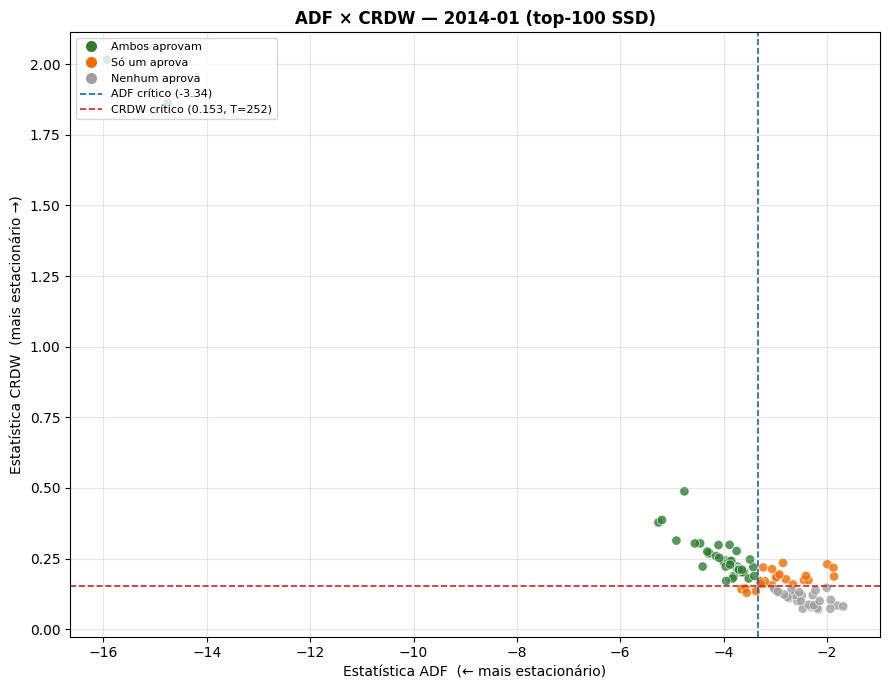

Salvo em: output/comparacao_adf_crdw_scatter.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

cores = []
for _, r in df_comp.iterrows():
    if r['adf_uni'] and r['crdw_uni']:
        cores.append('#2e7d32')   # ambos aprovam
    elif r['adf_uni'] or r['crdw_uni']:
        cores.append('#ef6c00')   # só um aprova (divergência)
    else:
        cores.append('#9e9e9e')   # nenhum aprova

ax.scatter(df_comp['adf_stat'], df_comp['crdw_stat'], c=cores, s=45, alpha=0.8, edgecolors='white', lw=0.5)
ax.axvline(CRIT_COINT_5PCT, color='#1565C0', ls='--', lw=1.2, label=f'ADF crítico ({CRIT_COINT_5PCT})')
ax.axhline(CRIT_CRDW_5PCT,  color='#C62828', ls='--', lw=1.2, label=f'CRDW crítico ({CRIT_CRDW_5PCT:.3f}, T={Q.shape[0]})')

ax.set_xlabel('Estatística ADF  (← mais estacionário)', fontsize=10)
ax.set_ylabel('Estatística CRDW  (mais estacionário →)', fontsize=10)
ax.set_title(f'ADF × CRDW — {FORM_INICIO} (top-{TOP_N_SSD} SSD)', fontsize=12, fontweight='bold')

from matplotlib.lines import Line2D
legenda = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2e7d32', markersize=9, label='Ambos aprovam'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#ef6c00', markersize=9, label='Só um aprova'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#9e9e9e', markersize=9, label='Nenhum aprova'),
]
ax.legend(handles=legenda + ax.get_legend_handles_labels()[0], fontsize=8, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('output/comparacao_adf_crdw_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em: output/comparacao_adf_crdw_scatter.png')

## 7. Pares onde ADF e CRDW divergem

São os casos mais informativos para o TCC: um teste aprova e o outro reprova o mesmo par.

In [7]:
divergentes = df_comp[df_comp['adf_uni'] != df_comp['crdw_uni']].copy()
divergentes['quem_aprova'] = np.where(divergentes['adf_uni'], 'só ADF', 'só CRDW')

print(f"Pares divergentes (unilateral): {len(divergentes)} de {len(df_comp)}\n")
display(
    divergentes[['par', 'ssd', 'adf_stat', 'adf_uni', 'crdw_stat', 'crdw_uni', 'quem_aprova']]
    .sort_values('ssd')
    .reset_index(drop=True)
)

Pares divergentes (unilateral): 26 de 100



,par,ssd,adf_stat,adf_uni,crdw_stat,crdw_uni,quem_aprova
0,AEP-CMS,0.0662,-2.851,False,0.235,True,só CRDW
1,EQR-AVB,0.0795,-3.292,False,0.163,True,só CRDW
2,MMM-ITW,0.0952,-3.232,False,0.219,True,só CRDW
3,ALL-BRK_B,0.1192,-2.445,False,0.174,True,só CRDW
4,BBT-RF,0.1238,-3.238,False,0.160,True,só CRDW
5,PBCT-ARG,0.1251,-1.992,False,0.230,True,só CRDW
6,NEE-PPL,0.1270,-2.359,False,0.174,True,só CRDW
7,CL-MKC,0.1272,-3.067,False,0.157,True,só CRDW
8,CPB-TMK,0.1285,-1.874,False,0.218,True,só CRDW
9,MMM-TRV,0.1290,-2.961,False,0.187,True,só CRDW


## 8. Salvando a tabela comparativa

In [8]:
df_comp.to_csv('output/comparacao_adf_crdw.csv', index=False)
print('Salvo: output/comparacao_adf_crdw.csv')

Salvo: output/comparacao_adf_crdw.csv
